# Replication materials for the CleverMiner article
This notebook contains replication material for the article. For reference, please see the main article.

The structure is the following:

* Setup of prerequisites
* Imports and data load
* Sample tasks - Replication material for code in individual sections
  * (Section 5.1) Example of 4ft-Miner
  * (Section 5.2) Example of embedding CleverMiner/using own measure of interestingness and handling results
  * (Section 5.3) Illustrative example for Act+Miner 
  * (Section 4.3) Replication material for performance test (real number of verifications needed)


**MAKE SURE THAT YOU HAVE UNPACKED THE ENTIRE PACKAGE** 
You need to have at least *requirements.txt* in the same folder as this notebook and *accidents.zip* in ./code/data to run this notebook correctly.


# Setup of Prerequisites

In [1]:
%pip install -r requirements.txt

  Using cached pandas-3.0.2-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached progressbar2-4.5.0-py3-none-any.whl.metadata (16 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cleverminer-1.2.4-py3-none-any.whl.metadata (7.9 kB)
  Using cached PyQt5-5.15.11-cp38-abi3-manylinux_2_17_x86_64.whl.metadata (2.1 kB)
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached python_utils-3.9.1-py2.py3-none-any.whl.metadata (9.8 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-a

# Imports and data load

In [2]:
import pandas as pd
from sklearn.impute import SimpleImputer
from cleverminer import cleverminer
from cleverminer.actplusminer import actplusminer
from matplotlib import pyplot as plt
import seaborn as sns
import math

df = pd.read_csv ('./code/data/accidents.zip', encoding='cp1250', sep='\t')
df=df[['Driver_Age_Band','Driver_IMD','Sex','Area','Journey','Road_Type','Speed_limit','Light','Vehicle_Location','Vehicle_Type','Vehicle_Age','Hit_Objects_in','Hit_Objects_off','Casualties','Severity']]

#fill in missing values

imputer = SimpleImputer(strategy="most_frequent")
df = pd.DataFrame(imputer.fit_transform(df),columns = df.columns)

Cleverminer version  1.2.4


/tmp/ipykernel_3930/230914543.py:9: DtypeWarning: Columns (0: Casualties, 1: District2+) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv ('./code/data/accidents.zip', encoding='cp1250', sep='\t')


# Sample tasks

## (Section 5.1) Example of 4ft-Miner 

First, we will define the task. 

We will use attributes *Driver_Age_Band*, *Vehicle_Type*, *Sex*, *Speed_limit* and *Journey* in the antecedent (left-hand side of the rule) and *Severity* in the succedent (right-hand side of the rule).

To limit the number of possible combinations of attributes (and also to have rules that we can reasonably interpret), we will set that:
* *Driver_Age_Band* and *Speed_limit* - we will consider that these variables are ordinal (ordered bands) and we allow category joining (can be used 1-3 categories in the literal of the rule).
* *Severity* - we are looking only for the leftmost category (in our case Fatal)
* All remaining attributes (i.e. *Vehicle_Type*, *Journey* and *Sex*), will have only 1 category in each rule (if the attribute appears in the rule).
* In antecedent (left-hand side of the rule), we want only combinations of 1 to 4 attributes

In [3]:
clm = cleverminer(df=df,proc='4ftMiner',
               quantifiers= {'Base':2000, 'aad':1.0},
               ante ={
                    'attributes':[
                        {'name': 'Driver_Age_Band', 'type': 'seq', 'minlen': 1, 'maxlen': 3},
                        {'name': 'Vehicle_Type', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
                        {'name': 'Sex', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
                        {'name': 'Speed_limit', 'type': 'seq', 'minlen': 1, 'maxlen': 3},
                        {'name': 'Journey', 'type': 'subset', 'minlen': 1, 'maxlen': 1}
                    ], 'minlen':1, 'maxlen':4, 'type':'con'},
               succ ={
                    'attributes':[
                        {'name': 'Severity', 'type': 'lcut', 'minlen': 1, 'maxlen': 1}
                    ], 'minlen':1, 'maxlen':1 , 'type':'con'}
                  ,opts = {'keep_df':True}
                  )

clm.print_summary()

Cleverminer version 1.2.4.
Starting data preparation ...
Automatically reordering numeric categories ...
Automatically reordering numeric categories ...done
Encoding columns into bit-form...
Encoding columns into bit-form...done
Data preparation finished.
Will go for  4ftMiner
Starting to mine rules.
100%|####################################################|Elapsed Time: 0:00:0101
Done. Total verifications : 228, rules 9, times: prep 1.32sec, processing 1.90sec

CleverMiner task processing summary:

Task type : 4ftMiner
Number of verifications : 228
Number of rules : 9
Total time needed : 00h 00m 03s
Time of data preparation : 00h 00m 01s
Time of rule mining : 00h 00m 01s



To be sure, we will verify the correctness of the ordering of the categories (how CleverMiner understands it). So we will look at how CleverMiner ordered the categories.

In [4]:
clm.print_data_definition()

Dataset has 15 variables.
Variable Driver_Age_Band has 8 categories: 16 - 20 21 - 25 26 - 35 36 - 45 46 - 55 56 - 65 66 - 75 Over 75
Variable Driver_IMD has 10 categories: 1 2 3 4 5 6 7 8 9 10
Variable Sex has 2 categories: Female Male
Variable Area has 2 categories: 1,Urban 2,Rural
Variable Journey has 5 categories: 2,Commuting to/from work 3,Taking pupil to/from school 4,Pupil riding to/from school 5 Other/Not known Part of work
Variable Road_Type has 5 categories: 1,Roundabout 2,One way street 3,Dual carriageway 6,Single carriageway 7,Slip road
Variable Speed_limit has 8 categories: 10 15 20 30 40 50 60 70
Variable Light has 5 categories: 1,Daylight 4,Darkness - lights lit 5,Darkness - lights unlit 6,Darkness - no lighting 7,Darkness - lighting unknown
Variable Vehicle_Location has 10 categories: 0,On main c'way - not in restricted lane 1,Tram/Light rail track 2,Bus lane 3,Busway (including guided busway) 4,Cycle lane (on main carriageway) 5,Cycleway or shared use footway (not part 

We can see that 
* the variable *Driver_Age_Band* is ordered correctly. Values are ordered in the following way: 16 - 20 21 - 25 26 - 35 36 - 45 46 - 55 56 - 65 66 - 75 Over 75.
* also the *Speed_limit* is ordered correctly - ordered values are 10 15 20 30 40 50 60 70

So we can be sure that only adjacent categories have been joined.


Now, we will look at the list of rules

In [5]:
clm.print_rulelist()


List of rules:
RULEID BASE  CONF  AAD    Rule
     1  2135 0.040 +1.098 Driver_Age_Band(26 - 35 36 - 45 46 - 55) & Sex(Male) & Speed_limit(50 60 70) => Severity(Fatal) | ---
     2  2362 0.039 +1.056 Vehicle_Type(Car) & Sex(Male) & Speed_limit(50 60 70) & Journey(5 Other/Not known) => Severity(Fatal) | ---
     3  2138 0.039 +1.041 Vehicle_Type(Car) & Sex(Male) & Speed_limit(60 70) & Journey(5 Other/Not known) => Severity(Fatal) | ---
     4  3089 0.040 +1.079 Sex(Male) & Speed_limit(40 50 60) & Journey(5 Other/Not known) => Severity(Fatal) | ---
     5  2436 0.040 +1.094 Sex(Male) & Speed_limit(50 60) & Journey(5 Other/Not known) => Severity(Fatal) | ---
     6  4050 0.039 +1.017 Sex(Male) & Speed_limit(50 60 70) => Severity(Fatal) | ---
     7  3151 0.041 +1.145 Sex(Male) & Speed_limit(50 60 70) & Journey(5 Other/Not known) => Severity(Fatal) | ---
     8  2110 0.039 +1.054 Sex(Male) & Speed_limit(60) & Journey(5 Other/Not known) => Severity(Fatal) | ---
     9  2825 0.041 +1.119 Se

We can also list details about each rule. We will show the details about rule 1 in both text and graphical form.



Rule id : 1

Base :  2135  Relative base : 0.004  CONF : 0.040  AAD : +1.098  BAD : -1.098

Cedents:
  antecedent : Driver_Age_Band(26 - 35 36 - 45 46 - 55) & Sex(Male) & Speed_limit(50 60 70)
  succcedent : Severity(Fatal)
  condition  : ---

Fourfold table
    |  S  |  ¬S |
----|-----|-----|
 A  | 2135|50861|
----|-----|-----|
¬A  | 8214|477779|
----|-----|-----|




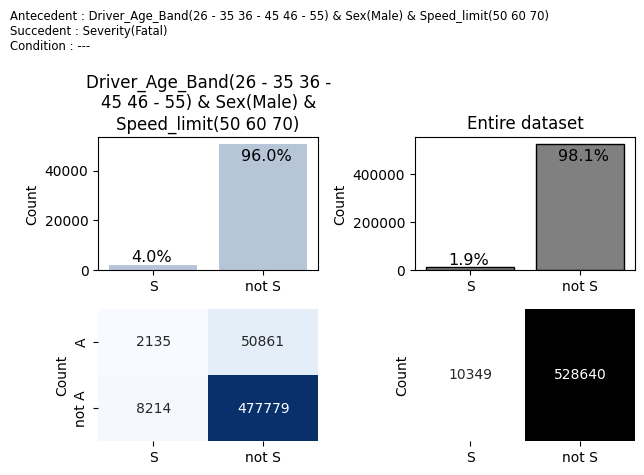

In [6]:
clm.print_rule(1)
clm.draw_rule(1)

This rule says that male drivers aged between 26 and 55 have a higher risk of a fatal accident at speed limits 50 to 70, namely 4.0% (compared to 1.9% in the entire dataset), which is +109.8% (see AAD 1.098). 

## (Section 5.2) Example of embedding CleverMiner/using own measure of interestingness and handling results

We will demonstrate how CleverMiner can be embedded. We want to use own metrics for rule post filtering.

### First, we will run the similar task as in previous example with lower bounds.

In [7]:
clm = cleverminer(df=df,proc='4ftMiner',
               quantifiers= {'Base':1000, 'aad':0.4},
               ante ={
                    'attributes':[
                        {'name': 'Driver_Age_Band', 'type': 'seq', 'minlen': 1, 'maxlen': 3},
                        {'name': 'Vehicle_Type', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
                        {'name': 'Sex', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
                        {'name': 'Speed_limit', 'type': 'seq', 'minlen': 1, 'maxlen': 3},
                        {'name': 'Journey', 'type': 'subset', 'minlen': 1, 'maxlen': 1}
                    ], 'minlen':1, 'maxlen':4, 'type':'con'},
               succ ={
                    'attributes':[
                        {'name': 'Severity', 'type': 'lcut', 'minlen': 1, 'maxlen': 1}
                    ], 'minlen':1, 'maxlen':1 , 'type':'con'}
                  ,opts = {'keep_df':True}
                  )

Cleverminer version 1.2.4.
Starting data preparation ...
Automatically reordering numeric categories ...
Automatically reordering numeric categories ...done
Encoding columns into bit-form...
Encoding columns into bit-form...done
Data preparation finished.
Will go for  4ftMiner
Starting to mine rules.
100%|####################################################|Elapsed Time: 0:00:0202
Done. Total verifications : 722, rules 238, times: prep 1.01sec, processing 2.48sec


We can look at the number of rules and processing summary.

In [8]:
clm.print_rulelist()
clm.print_summary()


List of rules:
RULEID BASE  CONF  AAD    Rule
     1  2092 0.028 +0.442 Driver_Age_Band(16 - 20 21 - 25) & Vehicle_Type(Car) & Sex(Male) => Severity(Fatal) | ---
     2  1151 0.034 +0.766 Driver_Age_Band(16 - 20 21 - 25) & Vehicle_Type(Car) & Sex(Male) & Speed_limit(40 50 60) => Severity(Fatal) | ---
     3  1098 0.033 +0.719 Driver_Age_Band(16 - 20 21 - 25) & Vehicle_Type(Car) & Sex(Male) & Speed_limit(50 60 70) => Severity(Fatal) | ---
     4  1878 0.029 +0.522 Driver_Age_Band(16 - 20 21 - 25) & Vehicle_Type(Car) & Sex(Male) & Journey(5 Other/Not known) => Severity(Fatal) | ---
     5  1380 0.028 +0.436 Driver_Age_Band(16 - 20 21 - 25) & Vehicle_Type(Car) & Speed_limit(40 50 60) => Severity(Fatal) | ---
     6  1222 0.030 +0.573 Driver_Age_Band(16 - 20 21 - 25) & Vehicle_Type(Car) & Speed_limit(40 50 60) & Journey(5 Other/Not known) => Severity(Fatal) | ---
     7  1174 0.029 +0.495 Driver_Age_Band(16 - 20 21 - 25) & Vehicle_Type(Car) & Speed_limit(50 60 70) & Journey(5 Other/Not kn


Now, prepare a new list of rules that satisfy the new measure of interestingness
* loop over the rule list; for each rule:
* get fourfold table via API
* calculate a custom measure of interestingness (combines support and confidence)
* if interestingness is over a threshold, append to a new list

In [9]:
d = []
dg = []
ordr = 0
for i in range(clm.get_rulecount()):
    ff = clm.get_fourfold(i+1)
    conf = None
    if ff[0]+ff[1]>0:
        conf = ff[0]/(ff[0]+ff[1])
    base = ff[0]
    interestingness = base/500 + 5*math.exp(50*(conf-0.019))
    dg_record = {
            'Rule_id': i + 1,
            'Base': base,
            'Order': "",
            'Confidence': conf,
            'Hue': '2',
            'Interestingness': interestingness,
            'Text': clm.get_ruletext(i + 1)
        }
    if interestingness > 19: #ignore this condition to get chart for all data [e.g., use interestingness >0]
        ordr += 1
        d.append(
            {
                'Rule_id': i + 1,
                'Order': ordr,
                'Base': base,
                'Confidence': conf,
                'Interestingness': interestingness,
                'Text': clm.get_ruletext(i + 1)
            })
        dg_record['Hue']='6'
        dg_record['Order'] = ordr
    dg.append(dg_record)

Draw a scatterplot with rules from the new list

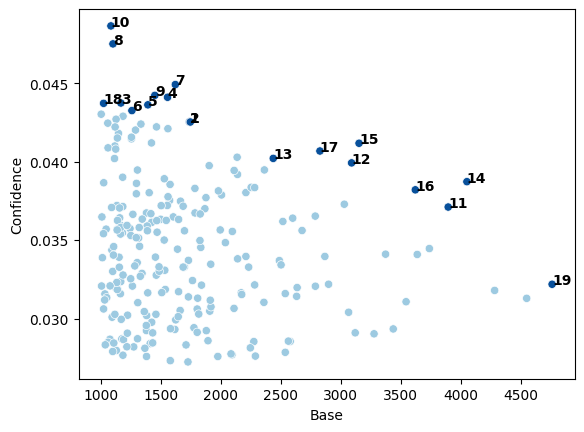

In [10]:
df_r = pd.DataFrame(dg)
ax=sns.scatterplot(data=df_r,x="Base",y="Confidence",hue="Hue",hue_order=['0','1','2','3','4','5','6'],palette="Blues",legend=False)
for line in range(0, df_r.shape[0]):
    ax.text(df_r["Base"][line] + 0.01, df_r["Confidence"][line],
            str(df_r["Order"][line]), horizontalalignment='left',
            size='medium', color='black', weight='semibold')

Print all rules in the new list

In [11]:
print(f"#   OrigId  Score  Base  Conf    Rule")
for i in range(ordr):
    print(f"{i+1:>3d}    {d[i]['Rule_id']:>3d}  {d[i]['Interestingness']:.2f}  {d[i]['Base']}  {d[i]['Confidence']:.4f} {d[i]['Text']}")

plt.show()

#   OrigId  Score  Base  Conf    Rule
  1     96  19.70  1738  0.0425  Driver_Age_Band(21 - 25 26 - 35 36 - 45) & Sex(Male) & Speed_limit(40 50 60) & Journey(5 Other/Not known) => Severity(Fatal) | ---
  2    100  19.71  1745  0.0425  Driver_Age_Band(21 - 25 26 - 35 36 - 45) & Sex(Male) & Speed_limit(50 60 70) & Journey(5 Other/Not known) => Severity(Fatal) | ---
  3    148  19.56  1166  0.0437  Driver_Age_Band(26 - 35 36 - 45 46 - 55) & Sex(Male) & Speed_limit(50 60) & Journey(5 Other/Not known) => Severity(Fatal) | ---
  4    150  20.66  1555  0.0441  Driver_Age_Band(26 - 35 36 - 45 46 - 55) & Sex(Male) & Speed_limit(50 60 70) & Journey(5 Other/Not known) => Severity(Fatal) | ---
  5    154  19.91  1391  0.0436  Driver_Age_Band(26 - 35 36 - 45 46 - 55) & Sex(Male) & Speed_limit(60 70) & Journey(5 Other/Not known) => Severity(Fatal) | ---
  6    166  19.34  1258  0.0433  Driver_Age_Band(36 - 45 46 - 55) & Sex(Male) & Speed_limit(50 60 70) => Severity(Fatal) | ---
  7    176  21.51  16

## (Section 5.3) Illustrative example for Act+Miner 

First, let us start with the same example as in the first demo. The task is repeated for clarity.

In [12]:
clm = cleverminer(df=df,proc='4ftMiner',
               quantifiers= {'Base':2000, 'aad':1.0},
               ante ={
                    'attributes':[
                        {'name': 'Driver_Age_Band', 'type': 'seq', 'minlen': 1, 'maxlen': 3},
                        {'name': 'Vehicle_Type', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
                        {'name': 'Sex', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
                        {'name': 'Speed_limit', 'type': 'seq', 'minlen': 1, 'maxlen': 3},
                        {'name': 'Journey', 'type': 'subset', 'minlen': 1, 'maxlen': 1}
                    ], 'minlen':1, 'maxlen':4, 'type':'con'},
               succ ={
                    'attributes':[
                        {'name': 'Severity', 'type': 'lcut', 'minlen': 1, 'maxlen': 1}
                    ], 'minlen':1, 'maxlen':1 , 'type':'con'}
                  ,opts = {'keep_df':True}
                  )

Cleverminer version 1.2.4.
Starting data preparation ...
Automatically reordering numeric categories ...
Automatically reordering numeric categories ...done
Encoding columns into bit-form...
Encoding columns into bit-form...done
Data preparation finished.
Will go for  4ftMiner
Starting to mine rules.
100%|####################################################|Elapsed Time: 0:00:0101
Done. Total verifications : 228, rules 9, times: prep 1.00sec, processing 1.83sec


Again, to ensure that the ordering is correct, we will check how CleverMiner understands the dataset and whether it ordered the categories correctly

In [13]:
clm.print_data_definition()

Dataset has 15 variables.
Variable Driver_Age_Band has 8 categories: 16 - 20 21 - 25 26 - 35 36 - 45 46 - 55 56 - 65 66 - 75 Over 75
Variable Driver_IMD has 10 categories: 1 2 3 4 5 6 7 8 9 10
Variable Sex has 2 categories: Female Male
Variable Area has 2 categories: 1,Urban 2,Rural
Variable Journey has 5 categories: 2,Commuting to/from work 3,Taking pupil to/from school 4,Pupil riding to/from school 5 Other/Not known Part of work
Variable Road_Type has 5 categories: 1,Roundabout 2,One way street 3,Dual carriageway 6,Single carriageway 7,Slip road
Variable Speed_limit has 8 categories: 10 15 20 30 40 50 60 70
Variable Light has 5 categories: 1,Daylight 4,Darkness - lights lit 5,Darkness - lights unlit 6,Darkness - no lighting 7,Darkness - lighting unknown
Variable Vehicle_Location has 10 categories: 0,On main c'way - not in restricted lane 1,Tram/Light rail track 2,Bus lane 3,Busway (including guided busway) 4,Cycle lane (on main carriageway) 5,Cycleway or shared use footway (not part 

Now, print the rules and the summary

In [14]:
clm.print_summary()
clm.print_rulelist()


CleverMiner task processing summary:

Task type : 4ftMiner
Number of verifications : 228
Number of rules : 9
Total time needed : 00h 00m 02s
Time of data preparation : 00h 00m 00s
Time of rule mining : 00h 00m 01s


List of rules:
RULEID BASE  CONF  AAD    Rule
     1  2135 0.040 +1.098 Driver_Age_Band(26 - 35 36 - 45 46 - 55) & Sex(Male) & Speed_limit(50 60 70) => Severity(Fatal) | ---
     2  2362 0.039 +1.056 Vehicle_Type(Car) & Sex(Male) & Speed_limit(50 60 70) & Journey(5 Other/Not known) => Severity(Fatal) | ---
     3  2138 0.039 +1.041 Vehicle_Type(Car) & Sex(Male) & Speed_limit(60 70) & Journey(5 Other/Not known) => Severity(Fatal) | ---
     4  3089 0.040 +1.079 Sex(Male) & Speed_limit(40 50 60) & Journey(5 Other/Not known) => Severity(Fatal) | ---
     5  2436 0.040 +1.094 Sex(Male) & Speed_limit(50 60) & Journey(5 Other/Not known) => Severity(Fatal) | ---
     6  4050 0.039 +1.017 Sex(Male) & Speed_limit(50 60 70) => Severity(Fatal) | ---
     7  3151 0.041 +1.145 Sex(Male

The analyst found rule #1 to be interesting (too many fatal accidents). We will print it completely



Rule id : 1

Base :  2135  Relative base : 0.004  CONF : 0.040  AAD : +1.098  BAD : -1.098

Cedents:
  antecedent : Driver_Age_Band(26 - 35 36 - 45 46 - 55) & Sex(Male) & Speed_limit(50 60 70)
  succcedent : Severity(Fatal)
  condition  : ---

Fourfold table
    |  S  |  ¬S |
----|-----|-----|
 A  | 2135|50861|
----|-----|-----|
¬A  | 8214|477779|
----|-----|-----|




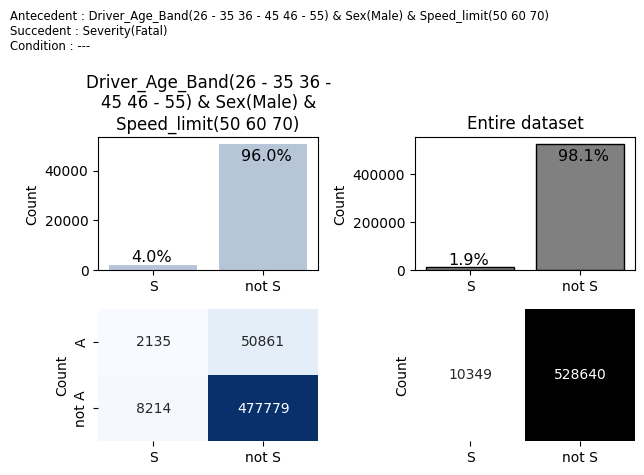

In [15]:
clm.print_rule(1)
clm.draw_rule(1)

We would like to know what we should change to reduce the number of fatal accidents. So now, we will find rules similar to rule #1 where *Sex* and *Driver_Age_Band* can be different (we consider that we can recommend a different driver for these circumstances -- at least in some cases) to find subgroups of drivers where the fatality rate is ≤50% of that in rule #1

In [16]:
apm = actplusminer(clm=clm,rule_id=1,quantifiers={'Base':100, 'confratio_leq': 0.5},ante_flex=[{'name': 'Sex', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
                        {'name': 'Driver_Age_Band', 'type': 'seq', 'minlen': 1, 'maxlen': 3}],succ_flex=None)

Cleverminer version 1.2.4.
Starting data preparation ...
Automatically reordering numeric categories ...
Automatically reordering numeric categories ...done
Encoding columns into bit-form...
Encoding columns into bit-form...done
Data preparation finished.
Will go for  4ftMiner
Starting to mine rules.
100%|####################################################|Elapsed Time: 0:00:00
Done. Total verifications : 36, rules 12, times: prep 0.99sec, processing 0.04sec


Now, we will print the results

In [17]:
apm.print_rulelist()


List of rules:
RULEID BASE  CONF  AAD    Rule
     1   135 0.014 -0.269 Driver_Age_Band(16 - 20) & Sex(Female) & Speed_limit(50 60 70) => Severity(Fatal) | ---
     2   252 0.014 -0.284 Driver_Age_Band(16 - 20 21 - 25) & Sex(Female) & Speed_limit(50 60 70) => Severity(Fatal) | ---
     3   397 0.014 -0.257 Driver_Age_Band(16 - 20 21 - 25 26 - 35) & Sex(Female) & Speed_limit(50 60 70) => Severity(Fatal) | ---
     4   117 0.013 -0.301 Driver_Age_Band(21 - 25) & Sex(Female) & Speed_limit(50 60 70) => Severity(Fatal) | ---
     5   262 0.014 -0.250 Driver_Age_Band(21 - 25 26 - 35) & Sex(Female) & Speed_limit(50 60 70) => Severity(Fatal) | ---
     6   379 0.015 -0.212 Driver_Age_Band(21 - 25 26 - 35 36 - 45) & Sex(Female) & Speed_limit(50 60 70) => Severity(Fatal) | ---
     7   145 0.015 -0.203 Driver_Age_Band(26 - 35) & Sex(Female) & Speed_limit(50 60 70) => Severity(Fatal) | ---
     8   262 0.016 -0.164 Driver_Age_Band(26 - 35 36 - 45) & Sex(Female) & Speed_limit(50 60 70) => Severit

All these rules have a fatality rate ≤50% of that in rule #1 for a different driver under the same circumstances. We may look at the details of new rule #3. We will also draw rule #1 (as the first one) for comparison.

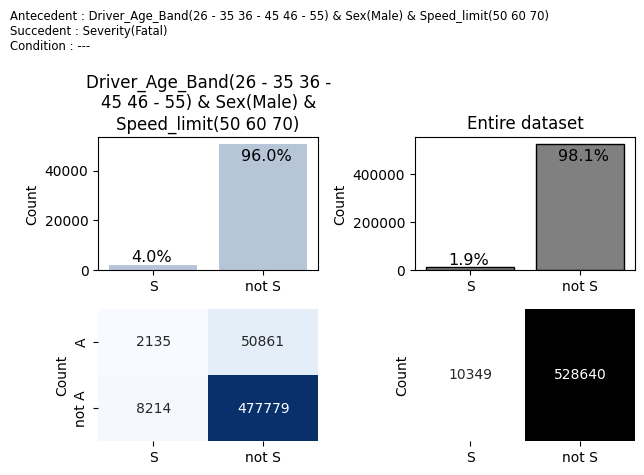

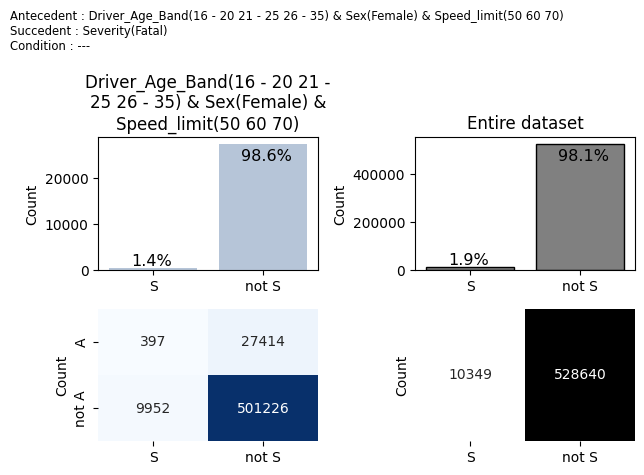

In [18]:
clm.draw_rule(1)
apm.draw_rule(3)

So we can see that when we would like to reduce the number of fatal accidents for male drivers aged 26-55 at speed limits 50-70, we might recommend switching to a female driver aged 16-35 if possible. The risk of fatal accidents will fall from 4% to 1.4%.

## (Section 4.3) Replication material for performance test (real number of verifications needed)

This code is just an example of how many rules will be really verified and also serves as an example of the reduction of combinatorial explosion in CleverMiner. Let us run the following code.

In [19]:
clm = cleverminer(df=df,proc='4ftMiner',
               quantifiers= {'Base':20000, 'aad':1.0},
               ante ={
                    'attributes':[
                        {'name': 'Driver_Age_Band', 'type': 'seq', 'minlen': 1, 'maxlen': 3},
                        {'name': 'Driver_IMD', 'type': 'seq', 'minlen': 1, 'maxlen': 3},
                        {'name': 'Sex', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
                        {'name': 'Journey', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
                        {'name': 'Area', 'type': 'subset', 'minlen': 1, 'maxlen': 2},
                        {'name': 'Road_Type', 'type': 'subset', 'minlen': 1, 'maxlen': 2},
                        {'name': 'Speed_limit', 'type': 'seq', 'minlen': 1, 'maxlen': 2},
                        {'name': 'Light', 'type': 'subset', 'minlen': 1, 'maxlen': 2},
                        {'name': 'Vehicle_Location', 'type': 'subset', 'minlen': 1, 'maxlen': 2},
                        {'name': 'Vehicle_Type', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
                        {'name': 'Vehicle_Age', 'type': 'seq', 'minlen': 1, 'maxlen': 11}
                    ], 'minlen':1, 'maxlen':3, 'type':'con'},
               succ ={
                    'attributes':[
                        {'name': 'Casualties', 'type': 'rcut', 'minlen': 1, 'maxlen': 6},
                        {'name': 'Severity', 'type': 'lcut', 'minlen': 1, 'maxlen': 2}
                    ], 'minlen':1, 'maxlen':1 , 'type':'con'}
               )

clm.print_rulelist()
clm.print_summary()

Cleverminer version 1.2.4.
Starting data preparation ...
Automatically reordering numeric categories ...
Automatically reordering numeric categories ...done
Encoding columns into bit-form...
Encoding columns into bit-form...done
Data preparation finished.
Will go for  4ftMiner
Starting to mine rules.
100%|####################################################|Elapsed Time: 0:02:4999
Done. Total verifications : 74000, rules 18, times: prep 1.00sec, processing 169.47sec

List of rules:
RULEID BASE  CONF  AAD    Rule
     1 23149 0.251 +1.121 Driver_Age_Band(16 - 20 21 - 25) & Journey(5 Other/Not known) & Vehicle_Type(Car) => Casualties(7 - 68 6 5 4 3 2) | ---
     2 22121 0.244 +1.067 Driver_Age_Band(16 - 20 21 - 25 26 - 35) & Journey(5 Other/Not known) & Area(2,Rural) => Casualties(7 - 68 6 5 4 3 2) | ---
     3 23561 0.238 +1.017 Journey(5 Other/Not known) & Area(1,Urban 2,Rural) & Speed_limit(60 70) => Casualties(7 - 68 6 5 4 3 2) | ---
     4 22483 0.240 +1.033 Journey(5 Other/Not know

We can see that we needed to verify only 74 000 possible rules for this task

Note that (for details, see the main article)
* there are approximately 3.18 x 10^27 possible rules (when not limiting the number of combinations and categories)
* there are 309 774 368 possible rules with limitations in rule finding but no optimizations in place.